## Visualize

In [2]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt

## Views

In [3]:
base_folder = "final_data/google_trends/"
trend_sweden = pd.read_csv(base_folder+"sweden.csv")
trend_italy = pd.read_csv(base_folder+"italy.csv")
trend_poland = pd.read_csv(base_folder+"poland.csv")
trend_russia = pd.read_csv(base_folder+"russia.csv")
trend_worldwide = pd.read_csv(base_folder+"worldwide.csv")

## 1. Map of how the Saliency changed in the year 2025 (Depending on the year)

aslkdfjlaksdfj

In [4]:
trend_russia.head()

,Time,Krieg in Israel und Gaza seit 2023
0,2024-12-29,0
1,2025-01-05,39
2,2025-01-12,88
3,2025-01-19,41
4,2025-01-26,66


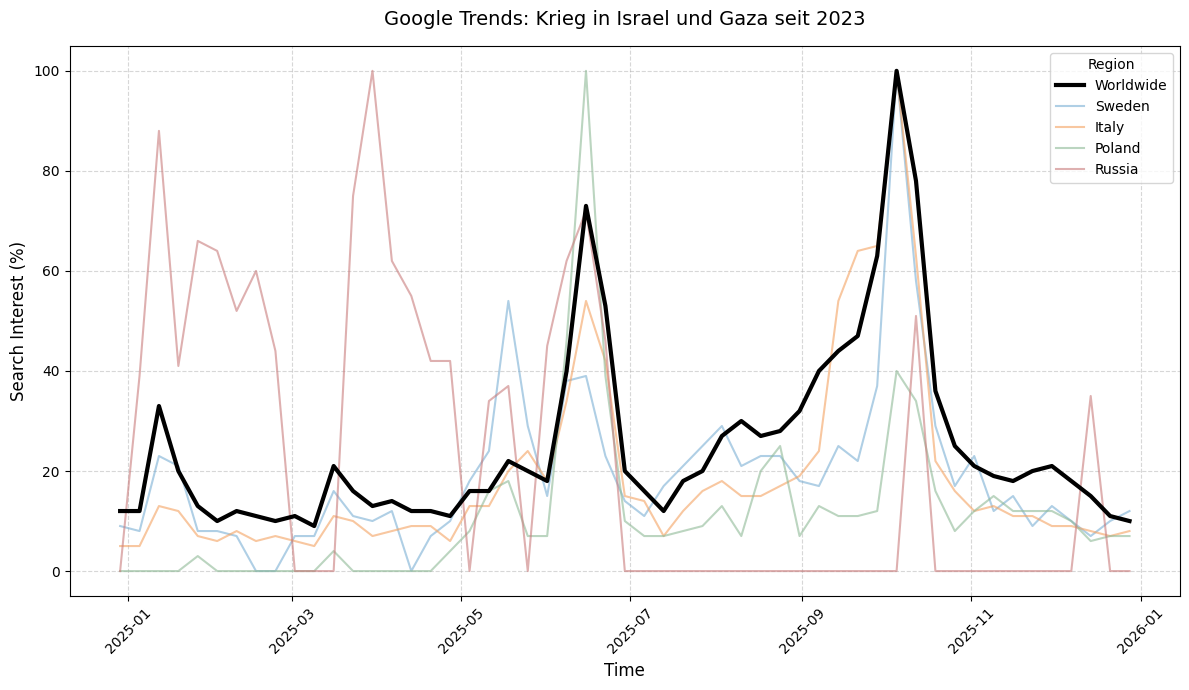

In [5]:
import matplotlib.pyplot as plt
import pandas as pd

trends_data = {
    "Sweden": trend_sweden,
    "Italy": trend_italy,
    "Poland": trend_poland,
    "Russia": trend_russia,
    "Worldwide": trend_worldwide
}

value_col = "Krieg in Israel und Gaza seit 2023"

# Dezente Farben für die Länder, Worldwide wird separat behandelt
country_styles = {
    "Sweden":    {"color": "#7BAFD4", "linewidth": 1.5, "alpha": 0.6, "zorder": 2},
    "Italy":     {"color": "#F4A261", "linewidth": 1.5, "alpha": 0.6, "zorder": 2},
    "Poland":    {"color": "#8FB996", "linewidth": 1.5, "alpha": 0.6, "zorder": 2},
    "Russia":    {"color": "#C97C7C", "linewidth": 1.5, "alpha": 0.6, "zorder": 2},
    "Worldwide": {"color": "#000000", "linewidth": 3.0, "alpha": 1.0,  "zorder": 5},
}

plt.figure(figsize=(12, 7))

for country_name, df in trends_data.items():
    df['Time'] = pd.to_datetime(df['Time'])
    df[value_col] = pd.to_numeric(
        df[value_col].astype(str).str.replace('<1', '0'), errors='coerce'
    )
    
    style = country_styles[country_name]
    plt.plot(
        df['Time'], df[value_col],
        label=country_name,
        color=style["color"],
        linewidth=style["linewidth"],
        alpha=style["alpha"],
        zorder=style["zorder"]
    )

plt.title(f"Google Trends: {value_col}", fontsize=14, pad=15)
plt.xlabel("Time", fontsize=12)
plt.ylabel("Search Interest (%)", fontsize=12)
plt.ylim(-5, 105)
plt.grid(True, linestyle='--', alpha=0.5)

# Worldwide in der Legende zuerst hervorheben
handles, labels = plt.gca().get_legend_handles_labels()
order = [labels.index("Worldwide")] + [i for i, l in enumerate(labels) if l != "Worldwide"]
plt.legend(
    [handles[i] for i in order],
    [labels[i] for i in order],
    title="Region"
)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## Visualize Views

In [6]:
df_views = pd.read_csv("final_data/data_views.csv", delimiter=";")

In [7]:
df_views.head()

,wiki_db,page_id,page_title,total_pageviews_2025,week1_view_count,week2_view_count,week3_view_count,week4_view_count,week5_view_count,week6_view_count,...,week44_view_count,week45_view_count,week46_view_count,week47_view_count,week48_view_count,week49_view_count,week50_view_count,week51_view_count,week52_view_count,week53_view_count
0,arwiki,7,ماء,72805,1624,2213,2099,2086,1937,1685,...,1023,1065,933,976,908,886,846,706,948,345
1,arwiki,38,رياضيات,77838,1433,2333,2450,2449,2358,2390,...,1321,1337,1304,1156,1167,1303,1093,958,843,299
2,arwiki,62,إستونيا,58163,900,1440,1515,1225,1172,1128,...,806,742,973,838,828,777,868,782,694,275
3,arwiki,76,تلفزة,27605,727,980,803,841,687,798,...,461,444,492,570,251,20,22,31,29,8
4,arwiki,77,A,31251,441,685,647,759,686,750,...,556,534,404,399,480,424,535,424,431,248


In [8]:
row = df_views[df_views["page_title"] == "Guerra_Israele-Hamas"].iloc[0]

In [9]:
week_cols = [c for c in df.columns if c.startswith('week') and c.endswith('view_count')]


In [10]:
# Use df_views instead of df
week_cols = [c for c in df_views.columns if c.startswith('week') and c.endswith('view_count')]
print(f"Found {len(week_cols)} week columns")  # Should print 53

row = df_views[df_views["page_title"] == "Guerra_Israele-Hamas"].iloc[0]

values = row[week_cols].values.astype(float)
values_pct = (values / values.max()) * 100


Found 53 week columns


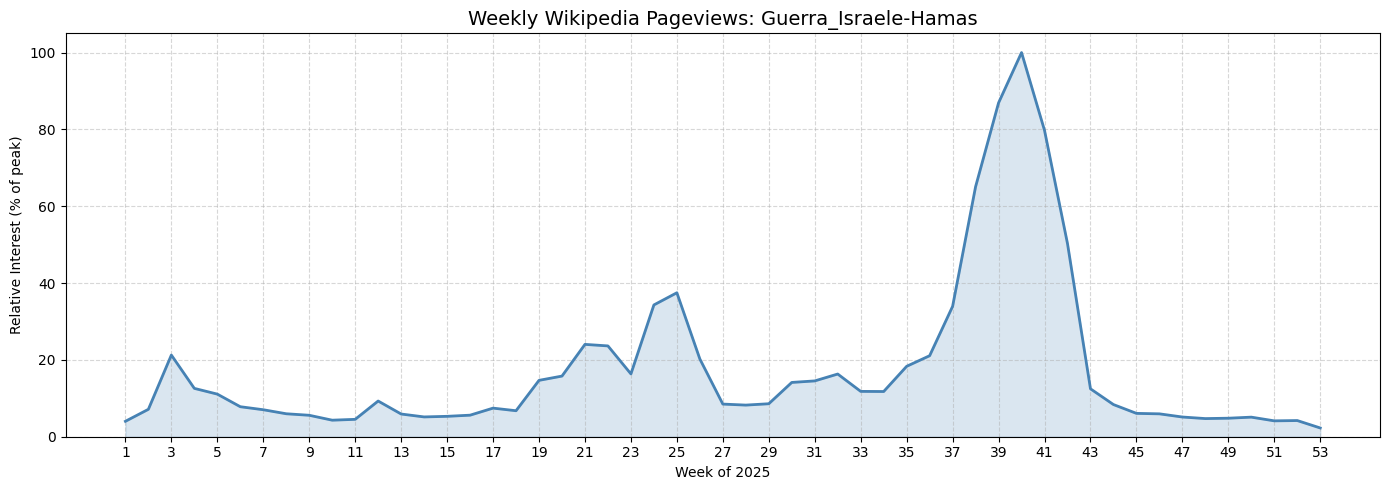

In [11]:
weeks = [int(c.replace('week', '').replace('_view_count', '')) for c in week_cols]

plt.figure(figsize=(14, 5))
plt.plot(weeks, values_pct, linewidth=2, color='steelblue')
plt.fill_between(weeks, values_pct, alpha=0.2, color='steelblue')  # works now

plt.title(f"Weekly Wikipedia Pageviews: {row['page_title']}", fontsize=14)
plt.xlabel("Week of 2025")
plt.ylabel("Relative Interest (% of peak)")
plt.ylim(0, 105)
plt.xticks(range(1, 54, 2))
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig("wiki_weekly_views.png")
plt.show()


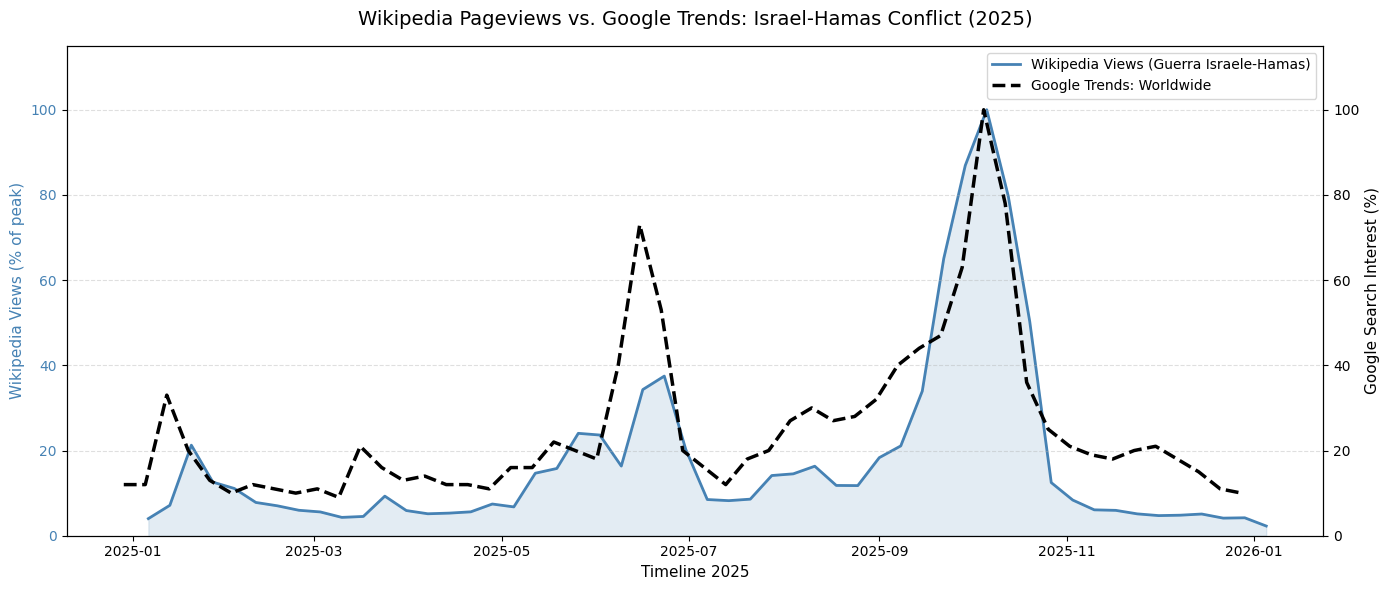

In [12]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd
import numpy as np

# --- Prepare Google Trends Worldwide ---
value_col = "Krieg in Israel und Gaza seit 2023"
df_ww = trend_worldwide.copy()
df_ww['Time'] = pd.to_datetime(df_ww['Time'])
df_ww[value_col] = pd.to_numeric(
    df_ww[value_col].astype(str).str.replace('<1', '0'), errors='coerce'
)

# --- Prepare Wikipedia weekly views ---
week_cols = [c for c in df_views.columns if c.startswith('week') and c.endswith('view_count')]
row = df_views[df_views["page_title"] == "Guerra_Israele-Hamas"].iloc[0]
values = row[week_cols].values.astype(float)
values_pct = (values / values.max()) * 100

# Map week numbers to actual dates (week 1 = first Monday of 2025)
week_dates = [pd.Timestamp('2025-01-06') + pd.Timedelta(weeks=i) for i in range(len(values))]

# --- Plot ---
fig, ax1 = plt.subplots(figsize=(14, 6))

# Wikipedia on ax1
ax1.fill_between(week_dates, values_pct, alpha=0.15, color='steelblue')
ax1.plot(week_dates, values_pct, color='steelblue', linewidth=2, label='Wikipedia Views (Guerra Israele-Hamas)')
ax1.set_ylabel("Wikipedia Views (% of peak)", color='steelblue', fontsize=11)
ax1.tick_params(axis='y', labelcolor='steelblue')
ax1.set_ylim(0, 115)

# Google Trends Worldwide on ax2
ax2 = ax1.twinx()
ax2.plot(df_ww['Time'], df_ww[value_col], color='black', linewidth=2.5,
         linestyle='--', label='Google Trends: Worldwide', zorder=5)
ax2.set_ylabel("Google Search Interest (%)", color='black', fontsize=11)
ax2.set_ylim(0, 115)

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

ax1.set_xlabel("Timeline 2025", fontsize=11)
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=45)
plt.title("Wikipedia Pageviews vs. Google Trends: Israel-Hamas Conflict (2025)", fontsize=14, pad=15)
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig("wiki_vs_trends.png")
plt.show()


In [13]:
page_titles ={
    "italian": "Guerra_Israele-Hamas",
    "german":"Krieg_in_Israel_und_Gaza_seit_2023",
    "poliski":"Wojna_Izraela_z_Hamasem",
    "russian":"Война_в_Газе",
    "sweden":"Kriget_i_Gaza_(pågående_sedan_2023)"
}

## this one

In [16]:
import plotly.graph_objects as go
import pandas as pd
import numpy as np
import json

!pip install --upgrade kaleido

page_titles = {
    "Italian": "Guerra_Israele-Hamas",
    "German":  "Krieg_in_Israel_und_Gaza_seit_2023",
    "Polish":  "Wojna_Izraela_z_Hamasem",
    "Russian": "Война_в_Газе",
    "Swedish": "Kriget_i_Gaza_(pågående_sedan_2023)"
}

wiki_colors = ["#5B8DB8", "#E07B54", "#6AAF6A", "#C97C7C", "#9B7EC8"]

# Prepare Worldwide Google Trends once
value_col = "Krieg in Israel und Gaza seit 2023"
df_ww = trend_worldwide.copy()
df_ww["Time"] = pd.to_datetime(df_ww["Time"])
df_ww[value_col] = pd.to_numeric(df_ww[value_col].astype(str).str.replace("<1", "0"), errors="coerce")
gt_pct = (df_ww[value_col] / df_ww[value_col].max()) * 100

week_cols  = [c for c in df_views.columns if c.startswith("week") and c.endswith("view_count")]
week_dates = [pd.Timestamp("2025-01-06") + pd.Timedelta(weeks=i) for i in range(len(week_cols))]

fig = go.Figure()

# Add Worldwide Trends once — shared black dotted reference line
fig.add_trace(go.Scatter(
    x=df_ww["Time"], y=gt_pct, mode="lines",
    name="Google Trends – Worldwide",
    line=dict(color="black", width=2.5, dash="dot"),
    legendgroup="worldwide", opacity=0.9,
))

for idx, (lang, title) in enumerate(page_titles.items()):
    row = df_views[df_views["page_title"] == title]
    if row.empty:
        print(f"WARNING: {title} not found"); continue
    values     = row.iloc[0][week_cols].values.astype(float)
    values_pct = (values / np.nanmax(values)) * 100

    fig.add_trace(go.Scatter(
        x=week_dates, y=values_pct, mode="lines",
        name=f"{lang} – Wikipedia",
        line=dict(color=wiki_colors[idx], width=2),
        legendgroup=lang, opacity=0.85,
    ))

fig.update_layout(
    title={"text": "Wikipedia Pageviews vs. Google Trends Worldwide (2025)<br>"
                   "<span style='font-size:15px;font-weight:normal'>"
                   "Solid = Wikipedia per language · Dotted = Google Trends Worldwide · % of peak</span>"},
    legend=dict(orientation="h", yanchor="bottom", y=1.08, xanchor="center", x=0.5),
    xaxis=dict(title_text="Timeline"),
    yaxis=dict(title_text="% of peak"),
    hovermode="x unified",
)


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

Figure({
    'data': [{'legendgroup': 'worldwide',
              'line': {'color': 'black', 'dash': 'dot', 'width': 2.5},
              'mode': 'lines',
              'name': 'Google Trends – Worldwide',
              'opacity': 0.9,
              'type': 'scatter',
              'x': array(['2024-12-29T00:00:00.000000000', '2025-01-05T00:00:00.000000000',
                          '2025-01-12T00:00:00.000000000', '2025-01-19T00:00:00.000000000',
                          '2025-01-26T00:00:00.000000000', '2025-02-02T00:00:00.000000000',
                          '2025-02-09T00:00:00.000000000', '2025-02-16T00:00:00.000000000',
                          '2025-02-23T00:00:00.000000000', '2025-03-02T00:00:00.000000000',
                          '2025-03-09T00:00:00.000000000', '2025-03-16T00:00:00.000000000',
                          '2025-03-23T00:00:00.000000000', '2025-03-30T00:00:00.000000000',
                          '2025-04-06T00:00:00.000000000', '2025-04-13T00:00:00.000000000',
                          '2025-04-20T00:00:00.000000000', '2025-04-27T00:00:00.000000000',
                          '2025-05-04T00:00:00.000000000', '2025-05-11T00:00:00.000000000',
                          '2025-05-18T00:00:00.000000000', '2025-05-25T00:00:00.000000000',
                          '2025-06-01T00:00:00.000000000', '2025-06-08T00:00:00.000000000',
                          '2025-06-15T00:00:00.000000000', '2025-06-22T00:00:00.000000000',
                          '2025-06-29T00:00:00.000000000', '2025-07-06T00:00:00.000000000',
                          '2025-07-13T00:00:00.000000000', '2025-07-20T00:00:00.000000000',
                          '2025-07-27T00:00:00.000000000', '2025-08-03T00:00:00.000000000',
                          '2025-08-10T00:00:00.000000000', '2025-08-17T00:00:00.000000000',
                          '2025-08-24T00:00:00.000000000', '2025-08-31T00:00:00.000000000',
                          '2025-09-07T00:00:00.000000000', '2025-09-14T00:00:00.000000000',
                          '2025-09-21T00:00:00.000000000', '2025-09-28T00:00:00.000000000',
                          '2025-10-05T00:00:00.000000000', '2025-10-12T00:00:00.000000000',
                          '2025-10-19T00:00:00.000000000', '2025-10-26T00:00:00.000000000',
                          '2025-11-02T00:00:00.000000000', '2025-11-09T00:00:00.000000000',
                          '2025-11-16T00:00:00.000000000', '2025-11-23T00:00:00.000000000',
                          '2025-11-30T00:00:00.000000000', '2025-12-07T00:00:00.000000000',
                          '2025-12-14T00:00:00.000000000', '2025-12-21T00:00:00.000000000',
                          '2025-12-28T00:00:00.000000000'], dtype='datetime64[ns]'),
              'y': {'bdata': ('AAAAAAAAKEAAAAAAAAAoQAAAAAAAgE' ... 'AAAC5AAAAAAAAAJkAAAAAAAAAkQA=='),
                    'dtype': 'f8'}},
             {'legendgroup': 'Italian',
              'line': {'color': '#5B8DB8', 'width': 2},
              'mode': 'lines',
              'name': 'Italian – Wikipedia',
              'opacity': 0.85,
              'type': 'scatter',
              'x': [2025-01-06 00:00:00, 2025-01-13 00:00:00, 2025-01-20 00:00:00,
                    2025-01-27 00:00:00, 2025-02-03 00:00:00, 2025-02-10 00:00:00,
                    2025-02-17 00:00:00, 2025-02-24 00:00:00, 2025-03-03 00:00:00,
                    2025-03-10 00:00:00, 2025-03-17 00:00:00, 2025-03-24 00:00:00,
                    2025-03-31 00:00:00, 2025-04-07 00:00:00, 2025-04-14 00:00:00,
                    2025-04-21 00:00:00, 2025-04-28 00:00:00, 2025-05-05 00:00:00,
                    2025-05-12 00:00:00, 2025-05-19 00:00:00, 2025-05-26 00:00:00,
                    2025-06-02 00:00:00, 2025-06-09 00:00:00, 2025-06-16 00:00:00,
                    2025-06-23 00:00:00, 2025-06-30 00:00:00, 2025-07-07 00:00:00,
                    2025-07-14 00:00:00, 2025-07-21 00:00:00, 2025-07-28 00:00:00,
                    2025-08-04 00:00:00, 2025-08-11

In [17]:
import pandas as pd
import numpy as np

# Prepare Worldwide Google Trends
value_col = "Krieg in Israel und Gaza seit 2023"
df_ww = trend_worldwide.copy()
df_ww["Time"] = pd.to_datetime(df_ww["Time"])
df_ww[value_col] = pd.to_numeric(df_ww[value_col].astype(str).str.replace("<1", "0"), errors="coerce")
gt_pct = (df_ww[value_col] / df_ww[value_col].max()) * 100

# Prepare Wikipedia weekly views
week_cols  = [c for c in df_views.columns if c.startswith("week") and c.endswith("view_count")]
week_dates = [pd.Timestamp("2025-01-06") + pd.Timedelta(weeks=i) for i in range(len(week_cols))]

page_titles = {
    "Italian": "Guerra_Israele-Hamas",
    "German":  "Krieg_in_Israel_und_Gaza_seit_2023",
    "Polish":  "Wojna_Izraela_z_Hamasem",
    "Russian": "Война_в_Газе",
    "Swedish": "Kriget_i_Gaza_(pågående_sedan_2023)"
}

# Resample Worldwide to weekly to match Wikipedia granularity
df_ww_weekly = df_ww.set_index("Time").resample("W-MON")[value_col].mean()
df_ww_weekly = (df_ww_weekly / df_ww_weekly.max()) * 100

results = []
for lang, title in page_titles.items():
    row = df_views[df_views["page_title"] == title]
    if row.empty:
        print(f"WARNING: {title} not found"); continue
    values     = row.iloc[0][week_cols].values.astype(float)
    values_pct = (values / np.nanmax(values)) * 100

    wiki_series = pd.Series(values_pct, index=pd.DatetimeIndex(week_dates))

    # Align both series on shared dates
    combined = pd.DataFrame({"wiki": wiki_series, "trends": df_ww_weekly}).dropna()

    pearson  = combined["wiki"].corr(combined["trends"], method="pearson")
    spearman = combined["wiki"].corr(combined["trends"], method="spearman")

    results.append({"Language": lang, "Pearson r": round(pearson, 3),
                    "Spearman ρ": round(spearman, 3), "n_weeks": len(combined)})

df_corr = pd.DataFrame(results).sort_values("Pearson r", ascending=False)
print(df_corr.to_string(index=False))


Language  Pearson r  Spearman ρ  n_weeks
 Italian      0.880       0.723       52
  Polish      0.805       0.727       52
  German      0.711       0.689       52
 Russian      0.529       0.574       52
 Swedish      0.513       0.576       52


In [18]:
# Quick lag check example
for lag in [0, 1, 2, 3]:
    shifted = combined["trends"].shift(lag)
    print(f"Lag {lag}w: {combined['wiki'].corr(shifted):.3f}")


Lag 0w: 0.513
Lag 1w: 0.585
Lag 2w: 0.272
Lag 3w: 0.050


In [19]:

for lang, title in page_titles.items():
    row = df_views[df_views["page_title"] == title]
    if row.empty: continue
    values = row.iloc[0][week_cols].values.astype(float)
    wiki_s = pd.Series((values / np.nanmax(values)) * 100, index=pd.DatetimeIndex(week_dates))
    combined = pd.DataFrame({"wiki": wiki_s, "trends": df_ww_weekly}).dropna()
    
    lags = {f"lag_{i}w": round(combined["wiki"].corr(combined["trends"].shift(i)), 3) for i in range(5)}
    print(f"{lang:10s}", lags)


Italian    {'lag_0w': 0.88, 'lag_1w': 0.804, 'lag_2w': 0.533, 'lag_3w': 0.293, 'lag_4w': 0.155}
German     {'lag_0w': 0.711, 'lag_1w': 0.86, 'lag_2w': 0.583, 'lag_3w': 0.251, 'lag_4w': 0.084}
Polish     {'lag_0w': 0.805, 'lag_1w': 0.933, 'lag_2w': 0.639, 'lag_3w': 0.306, 'lag_4w': 0.161}
Russian    {'lag_0w': 0.529, 'lag_1w': 0.797, 'lag_2w': 0.58, 'lag_3w': 0.309, 'lag_4w': 0.163}
Swedish    {'lag_0w': 0.513, 'lag_1w': 0.585, 'lag_2w': 0.272, 'lag_3w': 0.05, 'lag_4w': -0.034}


In [20]:
events = pd.read_csv("events.csv")

In [21]:
combined["wiki_diff"]   = combined["wiki"].diff()
combined["trends_diff"] = combined["trends"].diff()
pearson_diff = combined["wiki_diff"].corr(combined["trends_diff"])


In [22]:
event_weeks = pd.to_datetime(events["Date"]).dt.to_period("W")
combined_events = combined[combined.index.to_period("W").isin(event_weeks)]


In [23]:
from statsmodels.tsa.stattools import ccf
import numpy as np

# Drop NaN and convert to numpy arrays
wiki_vals   = combined["wiki"].dropna().values
trends_vals = combined["trends"].dropna().values

# Align lengths
min_len = min(len(wiki_vals), len(trends_vals))
wiki_vals, trends_vals = wiki_vals[:min_len], trends_vals[:min_len]

# CCF returns correlations for all lags — slice first 9 manually
cc = ccf(wiki_vals, trends_vals)
print({i: round(cc[i], 3) for i in range(9)})


{0: 0.513, 1: 0.587, 2: 0.277, 3: 0.052, 4: -0.035, 5: -0.005, 6: -0.084, 7: -0.047, 8: -0.066}


In [24]:
from statsmodels.tsa.stattools import ccf

for lang, title in page_titles.items():
    row = df_views[df_views["page_title"] == title]
    if row.empty: continue
    values = row.iloc[0][week_cols].values.astype(float)
    wiki_s = pd.Series((values / np.nanmax(values)) * 100, index=pd.DatetimeIndex(week_dates))
    combined = pd.DataFrame({"wiki": wiki_s, "trends": df_ww_weekly}).dropna()

    # First differences
    wiki_d   = combined["wiki"].diff().dropna().values
    trends_d = combined["trends"].diff().dropna().values
    min_len  = min(len(wiki_d), len(trends_d))

    cc = ccf(wiki_d[:min_len], trends_d[:min_len])
    top_lags = {i: round(cc[i], 3) for i in range(6)}
    best_lag = max(top_lags, key=top_lags.get)
    print(f"{lang:10s} best lag: {best_lag}w ({top_lags[best_lag]})  | all: {top_lags}")


Italian    best lag: 0w (0.584)  | all: {0: 0.584, 1: 0.573, 2: -0.073, 3: -0.331, 4: -0.166, 5: -0.081}
German     best lag: 1w (0.819)  | all: {0: 0.214, 1: 0.819, 2: 0.132, 3: -0.347, 4: -0.232, 5: -0.074}
Polish     best lag: 1w (0.834)  | all: {0: 0.447, 1: 0.834, 2: 0.094, 3: -0.398, 4: -0.152, 5: -0.057}
Russian    best lag: 1w (0.769)  | all: {0: 0.09, 1: 0.769, 2: 0.192, 3: -0.298, 4: -0.141, 5: -0.022}
Swedish    best lag: 1w (0.526)  | all: {0: 0.271, 1: 0.526, 2: -0.096, 3: -0.209, 4: -0.167, 5: 0.143}


In [26]:
import numpy as np
import pandas as pd
from statsmodels.tsa.stattools import ccf

for lang, title in page_titles.items():
    row = df_views[df_views["page_title"] == title]
    if row.empty: continue
    values = row.iloc[0][week_cols].values.astype(float)
    wiki_s = pd.Series((values / np.nanmax(values)) * 100, index=pd.DatetimeIndex(week_dates))
    combined = pd.DataFrame({"wiki": wiki_s, "trends": df_ww_weekly}).dropna()

    # First differences
    wiki_d   = combined["wiki"].diff().dropna().values
    trends_d = combined["trends"].diff().dropna().values
    min_len  = min(len(wiki_d), len(trends_d))
    
    # ---------------- NEU: Signifikanz berechnen ----------------
    N = min_len
    # Schwellenwert für 95% Konfidenz (alles darüber ist signifikant)
    conf_threshold = 1.96 / np.sqrt(N) 
    # ------------------------------------------------------------

    cc = ccf(wiki_d[:min_len], trends_d[:min_len])
    top_lags = {i: round(cc[i], 3) for i in range(6)}
    best_lag = max(top_lags, key=top_lags.get)
    best_corr = top_lags[best_lag]
    
    # Prüfen, ob der beste Wert über dem Schwellenwert liegt
    is_sig = "JA" if abs(best_corr) > conf_threshold else "NEIN"

    print(f"{lang:10s} best lag: {best_lag}w ({best_corr}) | Signifikant (95%): {is_sig} (Schwelle: {round(conf_threshold, 3)})")

Italian    best lag: 0w (0.584) | Signifikant (95%): JA (Schwelle: 0.274)
German     best lag: 1w (0.819) | Signifikant (95%): JA (Schwelle: 0.274)
Polish     best lag: 1w (0.834) | Signifikant (95%): JA (Schwelle: 0.274)
Russian    best lag: 1w (0.769) | Signifikant (95%): JA (Schwelle: 0.274)
Swedish    best lag: 1w (0.526) | Signifikant (95%): JA (Schwelle: 0.274)


In [28]:
import pandas as pd

# 1. Extract dates from the trends dataset to align with your D3 visualization
dates = trend_sweden['Time'].tolist()

# 2. The CORRECTED exact dictionary mappings
pages_to_extract = {
    "Guerra_Israele-Hamas": "Italy",
    "Wojna_Izraela_z_Hamasem": "Poland",
    "Kriget_i_Gaza_(pågående_sedan_2023)": "Sweden", 
    "Война_в_Газе": "Russia", 
    "Israel-Hamas_war": "Worldwide", # Using English for Worldwide
    "Israel–Hamas_war": "Worldwide"  # Catching the en-dash spelling variation just in case!
}

week_cols = [c for c in df_views.columns if c.startswith('week') and c.endswith('view_count')]

records = []
found_countries = []

for title, country_name in pages_to_extract.items():
    # Find the row for this specific wikipedia page
    row = df_views[df_views["page_title"] == title]
    
    if not row.empty:
        # Prevent duplicates if both English spellings are found
        if country_name not in found_countries: 
            found_countries.append(country_name)
            
            row = row.iloc[0]
            values = row[week_cols].values.astype(float)
            
            # Normalize to 0-100 (matching the Google Trends scale)
            values_pct = (values / values.max()) * 100
            
            # Pair each week's value with the corresponding date
            for date, val in zip(dates, values_pct):
                records.append({
                    "Country": country_name,
                    "Date": date,
                    "Interest": val
                })

# 3. Export to a single master CSV
df_views_master = pd.DataFrame(records)
df_views_master.to_csv("wikipedia_views.csv", index=False)

print(f"Exported wikipedia_views.csv successfully!")
print(f"Found data for: {', '.join(found_countries)}")

Exported wikipedia_views.csv successfully!
Found data for: Italy, Poland, Sweden, Russia


In [29]:
import pandas as pd
import numpy as np

# 1. Extract dates to align with your D3 visualization
dates = trend_sweden['Time'].tolist()

# 2. Load the edits data
df_edits = pd.read_csv("final_data/data_edits.csv", delimiter=";")

# 3. Exact mappings
pages_to_extract = {
    "Guerra_Israele-Hamas": "Italy",
    "Wojna_Izraela_z_Hamasem": "Poland",
    "Kriget_i_Gaza_(pågående_sedan_2023)": "Sweden", 
    "Война_в_Газе": "Russia", 
    "Israel-Hamas_war": "Worldwide", 
    "Israel–Hamas_war": "Worldwide" 
}

# Find week columns for edits 
week_cols = [c for c in df_edits.columns if c.startswith('week')]
if any('edit' in c for c in week_cols):
    week_cols = [c for c in week_cols if 'edit' in c]

records = []
found_countries = []

for title, country_name in pages_to_extract.items():
    row = df_edits[df_edits["page_title"] == title]
    
    if not row.empty:
        if country_name not in found_countries: 
            found_countries.append(country_name)
            
            row = row.iloc[0]
            values = row[week_cols].values.astype(float)
            
            # Normalize to 0-100 (Safeguard against 0 max edits)
            max_val = np.nanmax(values)
            values_pct = (values / max_val * 100) if max_val > 0 else np.zeros_like(values)
            
            # Pair each week's value with the corresponding date
            for date, val in zip(dates, values_pct):
                records.append({
                    "Country": country_name,
                    "Date": date,
                    "Interest": val
                })

# 4. Export to a single master CSV
df_edits_master = pd.DataFrame(records)
df_edits_master.to_csv("wikipedia_edits.csv", index=False)

print(f"Exported wikipedia_edits.csv successfully!")
print(f"Found edits data for: {', '.join(found_countries)}")

Exported wikipedia_edits.csv successfully!
Found edits data for: Italy, Poland, Sweden, Russia


In [33]:
import pandas as pd
import numpy as np

# 1. Extract dates to align with your D3 visualization
# (Make sure trend_sweden is already loaded in your notebook's memory)
dates = trend_sweden['Time'].tolist()

# 2. Load the edits data
df_edits = pd.read_csv("final_data/data_edits.csv", delimiter=";")

# 3. Exact mappings
pages_to_extract = {
    "Guerra_Israele-Hamas": "Italy",
    "Wojna_Izraela_z_Hamasem": "Poland",
    "Kriget_i_Gaza_(pågående_sedan_2023)": "Sweden", 
    "Война_в_Газе": "Russia", 
    "Israel-Hamas_war": "Worldwide", 
    "Israel–Hamas_war": "Worldwide" 
}

# Find week columns SPECIFICALLY for BAD edits 
week_cols = [c for c in df_edits.columns if c.startswith('week') and 'bad_edit' in c]

records = []
found_countries = []

for title, country_name in pages_to_extract.items():
    row = df_edits[df_edits["page_title"] == title]
    
    if not row.empty:
        if country_name not in found_countries: 
            found_countries.append(country_name)
            
            row = row.iloc[0]
            values = row[week_cols].values.astype(float)
            
            # Normalize to 0-100 (Safeguard against 0 max bad edits)
            max_val = np.nanmax(values)
            values_pct = (values / max_val * 100) if max_val > 0 else np.zeros_like(values)
            
            # Pair each week's value with the corresponding date
            for date, val in zip(dates, values_pct):
                records.append({
                    "Country": country_name,
                    "Date": date,
                    "Interest": val
                })

# 4. Export to a single master CSV for BAD EDITS
df_bad_edits_master = pd.DataFrame(records)
df_bad_edits_master.to_csv("wikipedia_bad_edits.csv", index=False)

print(f"Exported wikipedia_bad_edits.csv successfully!")
print(f"Found bad edits data for: {', '.join(found_countries)}")

Exported wikipedia_bad_edits.csv successfully!
Found bad edits data for: Italy, Poland, Sweden, Russia


In [30]:
# !pip install fastdtw scipy

  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Created wheel for fastdtw: filename=fastdtw-0.3.4-py3-none-any.whl size=3631 sha256=3228aac8fae530eb43ad6bc7d26cc460bc31e5e3d07588c7f4a6a5fdec131731
  Stored in directory: c:\users\feder\appdata\local\pip\cache\wheels\ab\d0\26\b82cb0f49ae73e5e6bba4e8462fff2c9851d7bd2ec64f8891e
Successfully built fastdtw



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [36]:
import pandas as pd
import numpy as np
from fastdtw import fastdtw

# 1. Load the data
df_views = pd.read_csv("wikipedia_views.csv")
df_edits = pd.read_csv("wikipedia_edits.csv")
df_bad_edits = pd.read_csv("wikipedia_bad_edits.csv")  # <-- Load bad edits

# 2. Load and prep Worldwide Google Trends (The Baseline for Views/Edits)
trend_worldwide = pd.read_csv("final_data/google_trends/worldwide.csv")

# Find the value column dynamically and clean it
date_col = 'Time' if 'Time' in trend_worldwide.columns else 'Date'
val_col = [c for c in trend_worldwide.columns if c not in [date_col, 'Country']][0]

trend_worldwide[val_col] = pd.to_numeric(
    trend_worldwide[val_col].astype(str).str.replace('<1', '0'), errors='coerce'
)
# Normalize global trends to 0-100 just in case
max_gt = trend_worldwide[val_col].max()
trend_worldwide['Global_Trend'] = (trend_worldwide[val_col] / max_gt) * 100

# Convert to list for DTW (Ensure chronological order)
trend_worldwide = trend_worldwide.sort_values(date_col)
global_trend_series = trend_worldwide['Global_Trend'].fillna(0).tolist()

# 3. Calculate DTW for each country
countries = df_views['Country'].unique()
results = []

# FIX: Use simple absolute difference for 1D scalar data
scalar_dist = lambda a, b: abs(a - b)

for country in countries:
    # --- VIEWS (vs Worldwide Google Trends) ---
    views_subset = df_views[df_views['Country'] == country].sort_values("Date")
    views_series = views_subset['Interest'].fillna(0).tolist()
    distance_views, path_views = fastdtw(global_trend_series, views_series, dist=scalar_dist)
    
    # --- EDITS (vs Worldwide Google Trends) ---
    edits_subset = df_edits[df_edits['Country'] == country].sort_values("Date")
    if not edits_subset.empty:
        edits_series = edits_subset['Interest'].fillna(0).tolist()
        distance_edits, path_edits = fastdtw(global_trend_series, edits_series, dist=scalar_dist)
    else:
        distance_edits = np.nan

    # --- BAD EDITS (vs Global Bad Edits) ---
    bad_edits_subset = df_bad_edits[df_bad_edits['Country'] == country].sort_values("Date")
    
    # Isolate all OTHER countries to create the "Global Bad Edits" baseline
    other_bad_edits = df_bad_edits[df_bad_edits['Country'] != country]
    
    if not bad_edits_subset.empty and not other_bad_edits.empty:
        # Group by Date and sum the interest to get the total worldwide bad edit volume
        global_bad_edits = other_bad_edits.groupby('Date')['Interest'].sum().reset_index()
        global_bad_edits = global_bad_edits.sort_values("Date")
        
        # Normalize the global sum back to 0-100 so it can be compared mathematically
        max_bad_val = global_bad_edits['Interest'].max()
        global_bad_edits['Interest_Norm'] = (global_bad_edits['Interest'] / max_bad_val * 100) if max_bad_val > 0 else 0
        
        # Convert both to lists
        bad_edits_series = bad_edits_subset['Interest'].fillna(0).tolist()
        global_bad_edits_series = global_bad_edits['Interest_Norm'].fillna(0).tolist()
        
        # Calculate DTW between the Local Bad Edits and the Global Bad Edits
        distance_bad_edits, path_bad_edits = fastdtw(global_bad_edits_series, bad_edits_series, dist=scalar_dist)
    else:
        distance_bad_edits = np.nan

    results.append({
        "Country / Language": country,
        "DTW (Views vs Google Trends)": round(distance_views, 2),
        "DTW (Edits vs Google Trends)": round(distance_edits, 2),
        "DTW (Bad Edits vs Global Bad Edits)": round(distance_bad_edits, 2)
    })

# 4. Display the results!
df_dtw = pd.DataFrame(results).sort_values("DTW (Views vs Google Trends)")
print("Dynamic Time Warping Distances (Lower Score = More Similar Shape)\n" + "-"*95)
print(df_dtw.to_string(index=False))

Dynamic Time Warping Distances (Lower Score = More Similar Shape)
-----------------------------------------------------------------------------------------------
Country / Language  DTW (Views vs Google Trends)  DTW (Edits vs Google Trends)  DTW (Bad Edits vs Global Bad Edits)
            Poland                        225.30                        728.56                               906.46
            Russia                        326.16                       1000.21                              1051.06
             Italy                        374.90                        529.19                               669.30
            Sweden                        379.08                        872.00                               728.15


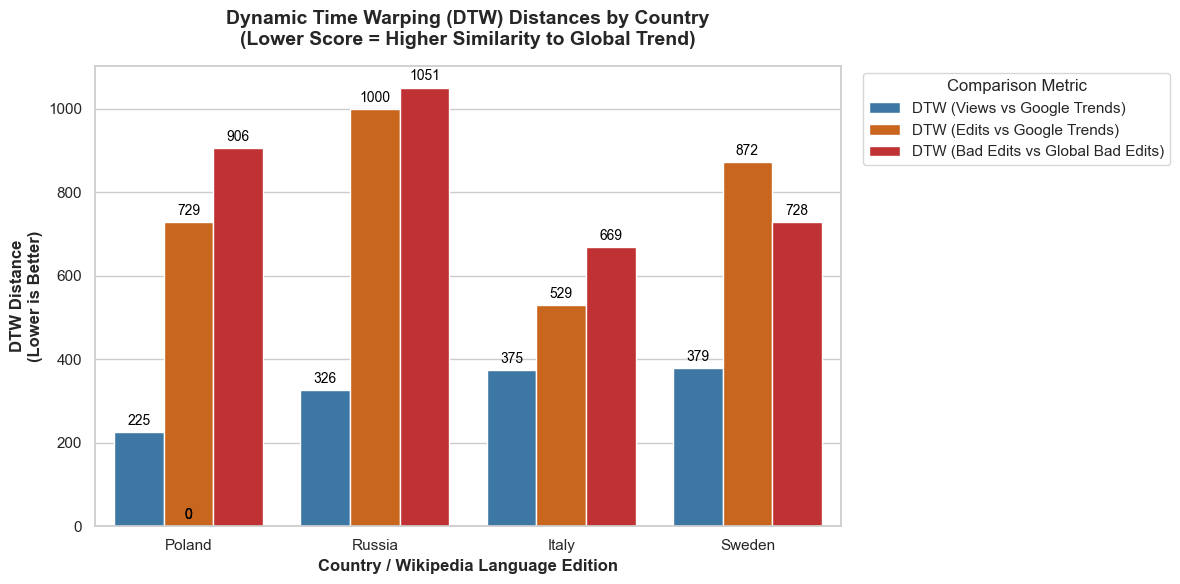

In [ ]:
import pandas as pd
import numpy as np
from fastdtw import fastdtw

# 1. Load the data
df_views = pd.read_csv("wikipedia_views.csv")
df_edits = pd.read_csv("wikipedia_edits.csv")
df_bad_edits = pd.read_csv("wikipedia_bad_edits.csv")

# 2. Load and prep Worldwide Google Trends
trend_worldwide = pd.read_csv("final_data/google_trends/worldwide.csv")
date_col = 'Time' if 'Time' in trend_worldwide.columns else 'Date'
val_col = [c for c in trend_worldwide.columns if c not in [date_col, 'Country']][0]

trend_worldwide[val_col] = pd.to_numeric(
    trend_worldwide[val_col].astype(str).str.replace('<1', '0'), errors='coerce'
)
max_gt = trend_worldwide[val_col].max()
trend_worldwide['Global_Trend'] = (trend_worldwide[val_col] / max_gt) * 100

trend_worldwide = trend_worldwide.sort_values(date_col)
global_trend_series = trend_worldwide['Global_Trend'].fillna(0).tolist()

# 3. Calculate NORMALIZED DTW for each country
countries = df_views['Country'].unique()
results = []
scalar_dist = lambda a, b: abs(a - b)

for country in countries:
    # --- VIEWS ---
    views_subset = df_views[df_views['Country'] == country].sort_values("Date")
    views_series = views_subset['Interest'].fillna(0).tolist()
    
    raw_dist_views, path_views = fastdtw(global_trend_series, views_series, dist=scalar_dist)
    norm_dist_views = raw_dist_views / len(path_views) # <-- NORMALIZATION
    
    # --- EDITS ---
    edits_subset = df_edits[df_edits['Country'] == country].sort_values("Date")
    if not edits_subset.empty:
        edits_series = edits_subset['Interest'].fillna(0).tolist()
        raw_dist_edits, path_edits = fastdtw(global_trend_series, edits_series, dist=scalar_dist)
        norm_dist_edits = raw_dist_edits / len(path_edits) # <-- NORMALIZATION
    else:
        norm_dist_edits = np.nan

    # --- BAD EDITS ---
    bad_edits_subset = df_bad_edits[df_bad_edits['Country'] == country].sort_values("Date")
    other_bad_edits = df_bad_edits[df_bad_edits['Country'] != country]
    
    if not bad_edits_subset.empty and not other_bad_edits.empty:
        global_bad_edits = other_bad_edits.groupby('Date')['Interest'].sum().reset_index()
        global_bad_edits = global_bad_edits.sort_values("Date")
        
        max_bad_val = global_bad_edits['Interest'].max()
        global_bad_edits['Interest_Norm'] = (global_bad_edits['Interest'] / max_bad_val * 100) if max_bad_val > 0 else 0
        
        bad_edits_series = bad_edits_subset['Interest'].fillna(0).tolist()
        global_bad_edits_series = global_bad_edits['Interest_Norm'].fillna(0).tolist()
        
        raw_dist_bad, path_bad = fastdtw(global_bad_edits_series, bad_edits_series, dist=scalar_dist)
        norm_dist_bad = raw_dist_bad / len(path_bad) # <-- NORMALIZATION
    else:
        norm_dist_bad = np.nan

    results.append({
        "Country": country,
        "Norm. DTW (Views vs Global)": round(norm_dist_views, 2),
        "Norm. DTW (Edits vs Global)": round(norm_dist_edits, 2),
        "Norm. DTW (Bad Edits vs Global)": round(norm_dist_bad, 2)
    })

# 4. Display the results!
df_dtw = pd.DataFrame(results).sort_values("Norm. DTW (Views vs Global)")
print("Normalized DTW Distances (Average % Gap per step. Lower = Better match)\n" + "-"*80)
print(df_dtw.to_string(index=False))